In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

from torch import nn
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim
import pytorch_optimizer as optim1
import optuna

from pytorch_lightning import LightningModule
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint, LearningRateMonitor
from pytorch_lightning.loggers import TensorBoardLogger
import pytorch_lightning as pl
from torchmetrics.classification import F1Score, MulticlassCohenKappa, Accuracy
pl.seed_everything(42)

Seed set to 42


42

In [99]:
df = pd.read_csv('synthetic+circle+data+set\circles.txt')
X = df.drop('class', axis=1)
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42, stratify=y_train)
X_train.shape, X_val.shape, X_test.shape

((6000, 2), (2000, 2), (2000, 2))

In [100]:
y_train.value_counts(), y_test.value_counts()

(class
 64    60
 3     60
 53    60
 17    60
 28    60
       ..
 13    60
 56    60
 41    60
 27    60
 60    60
 Name: count, Length: 100, dtype: int64,
 class
 59    20
 12    20
 56    20
 61    20
 88    20
       ..
 76    20
 15    20
 26    20
 46    20
 67    20
 Name: count, Length: 100, dtype: int64)

Visualisasi 3D telah disimpan sebagai 3d_scatter_plot.png


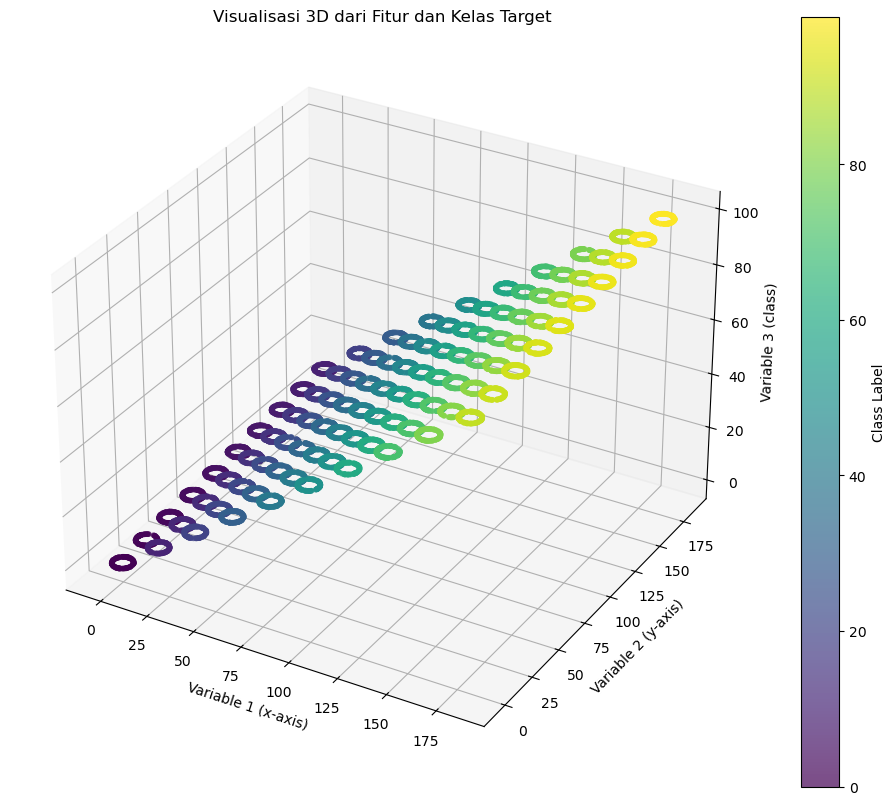

In [101]:
x = df['x']
y = df['y']
z_class = df['class']

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(x, y, z_class, c=z_class, cmap='viridis', marker='o', s=10, alpha=0.7)
ax.set_xlabel('Variable 1 (x-axis)')
ax.set_ylabel('Variable 2 (y-axis)')
ax.set_zlabel('Variable 3 (class)')
ax.set_title('Visualisasi 3D dari Fitur dan Kelas Target')
cbar = fig.colorbar(scatter, ax=ax, label='Class Label')
plt.savefig('3d_scatter_plot.png')
print("Visualisasi 3D telah disimpan sebagai 3d_scatter_plot.png")

In [102]:
bs = 128
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
X_val_tensor = torch.tensor(X_val.values, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.long)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(dataset=train_dataset, batch_size=bs, shuffle=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=bs, shuffle=False)
test_loader = DataLoader(dataset=test_dataset, batch_size=bs, shuffle=False)

print(f'Data siap! Ukuran set: Train={len(train_dataset)}, Validation={len(val_dataset)}, Test={len(test_dataset)}')

Data siap! Ukuran set: Train=6000, Validation=2000, Test=2000


In [103]:
class NN(nn.Module):
    def __init__(self, input_size, num_classes) -> None:
        super().__init__()

        self.fc = nn.Sequential(
            nn.Linear(input_size, 8),
            nn.Mish(),

            nn.Linear(8, 8),
            nn.BatchNorm1d(8),
            nn.Mish(),
            nn.Dropout(0.1),

            nn.Linear(8, 8),
            nn.BatchNorm1d(8),
            nn.Mish(),
            nn.Dropout(0.1),

            # nn.Linear(8, 8),
            # nn.BatchNorm1d(8),
            # nn.Mish(),
            # nn.Dropout(0.1),

            # nn.Linear(8, 8),
            # nn.BatchNorm1d(8),
            # nn.Mish(),
            # nn.Dropout(0.1),

            nn.Linear(8, num_classes)
        )

    def forward(self, X):
        return self.fc(X)

In [104]:
class PLNN(LightningModule):
    def __init__(self, input_size, num_classes=4, learning_rate=1e-3):
        super().__init__()
        self.save_hyperparameters() 
        self.model = NN(input_size=input_size, num_classes=num_classes)
        self.criterion = nn.CrossEntropyLoss()
        self.kappa = MulticlassCohenKappa(num_classes=num_classes, weights='quadratic')
        self.f1 = F1Score(task='multiclass', num_classes=num_classes, average='weighted')
        self.accurasy = Accuracy(task='multiclass', num_classes=num_classes)
    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        inputs, labels = batch
        outputs = self(inputs) 
        loss = self.criterion(outputs, labels)
        acc = self.accurasy(outputs, labels)
        f1 = self.accurasy(outputs, labels)
        kappa = self.accurasy(outputs, labels)

        
        self.log('train_loss', loss, on_epoch=True, prog_bar=True)
        self.log('train_f1', f1, on_epoch=True, prog_bar=True)
        self.log('train_acc', acc, on_epoch=True, prog_bar=True)
        self.log('train_kappa', kappa, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        inputs, labels = batch
        outputs = self(inputs)
        loss = self.criterion(outputs, labels)
        acc = self.accurasy(outputs, labels)
        f1 = self.accurasy(outputs, labels)
        kappa = self.accurasy(outputs, labels)


        self.log('val_loss', loss, on_epoch=True, prog_bar=True)
        self.log('val_f1', f1, on_epoch=True, prog_bar=True)
        self.log('val_acc', acc, on_epoch=True, prog_bar=True)
        self.log('val_kappa', kappa, on_epoch=True, prog_bar=True)

    def test_step(self, batch, batch_idx):
        inputs, labels = batch
        outputs = self(inputs)
        loss = self.criterion(outputs, labels)
        acc = self.accurasy(outputs, labels)
        f1 = self.accurasy(outputs, labels)
        kappa = self.accurasy(outputs, labels)


        self.log('test_loss', loss, on_epoch=True, prog_bar=True)
        self.log('test_f1', f1, on_epoch=True, prog_bar=True)
        self.log('test_acc', acc, on_epoch=True, prog_bar=True)
        self.log('test_kappa', kappa, on_epoch=True, prog_bar=True)

    def configure_optimizers(self):
        optimizer = optim1.AdamW(self.parameters(), lr=self.hparams.learning_rate)
        return optimizer

In [105]:
if torch.cuda.is_available():
    accelerator_type = 'gpu'
    devices_to_use = 1
else:
    accelerator_type = 'cpu'
    devices_to_use = 'auto'

checkpoint_callback = ModelCheckpoint(
    monitor='val_f1',
    dirpath='checkpoints/',
    filename='bodyP-{epoch:02d}-{val_f1:.2f}',
    save_top_k=1,
    mode='max'
)
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=40,
    mode='min'
)
lr_monitor_callback = LearningRateMonitor(logging_interval='epoch')

trainer1 = pl.Trainer(
    max_epochs=3000,
    callbacks=[checkpoint_callback, early_stopping, lr_monitor_callback],
    logger=TensorBoardLogger("tb_logs", name="simple_model_experiment"),
    accelerator=accelerator_type,
    devices=devices_to_use,
    log_every_n_steps=10,
    deterministic=True
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [106]:
model = PLNN(input_size=X_train.shape[1], num_classes=100, learning_rate=1e-3)
trainer1.fit(model, train_loader, val_loader)


  | Name      | Type                 | Params | Mode 
-----------------------------------------------------------
0 | model     | NN                   | 1.1 K  | train
1 | criterion | CrossEntropyLoss     | 0      | train
2 | kappa     | MulticlassCohenKappa | 0      | train
3 | f1        | MulticlassF1Score    | 0      | train
4 | accurasy  | MulticlassAccuracy   | 0      | train
-----------------------------------------------------------
1.1 K     Trainable params
0         Non-trainable params
1.1 K     Total params
0.004     Total estimated model params size (MB)
17        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

In [107]:
trainer1.validate(model, val_loader)

Validation: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│          val_acc          │    0.9909999966621399     │
│          val_f1           │    0.9909999966621399     │
│         val_kappa         │    0.9909999966621399     │
│         val_loss          │    0.6533010005950928     │
└───────────────────────────┴───────────────────────────┘

[{'val_loss': 0.6533010005950928,
  'val_f1': 0.9909999966621399,
  'val_acc': 0.9909999966621399,
  'val_kappa': 0.9909999966621399}]

In [108]:
trainer1.test(model, test_loader)

Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9900000095367432     │
│          test_f1          │    0.9900000095367432     │
│        test_kappa         │    0.9900000095367432     │
│         test_loss         │     0.649880588054657     │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.649880588054657,
  'test_f1': 0.9900000095367432,
  'test_acc': 0.9900000095367432,
  'test_kappa': 0.9900000095367432}]